# Clustering Menggunakan Metode (K-MEANS)

## Baca Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Penjelasan Dataset Kualitas Udara Yogyakarta

## Informasi Kolom

### 📅 Date
Tanggal pengukuran kualitas udara dilakukan.

---

### 🌫️ PM10 (Particulate Matter 10)
Partikel debu yang melayang di udara dengan diameter **≤ 10 mikrometer**.
- Contoh: debu jalanan, serbuk sari, abu industri
- Dapat masuk ke hidung dan tenggorokan
- Berbahaya bagi penderita asma dan alergi
- Satuan: µg/m³ (mikrogram per meter kubik)

---

### 🌫️ PM2.5 (Particulate Matter 2.5)
Partikel debu yang sangat halus dengan diameter **≤ 2.5 mikrometer**.
- Contoh: asap kendaraan, asap rokok, asap pabrik
- Lebih berbahaya dari PM10 karena bisa masuk ke paru-paru dan aliran darah
- Penyebab utama ISPA dan penyakit jantung
- Satuan: µg/m³ (mikrogram per meter kubik)

---

### 🟡 SO2 (Sulfur Dioxide / Sulfur Dioksida)
Gas yang dihasilkan dari pembakaran bahan bakar fosil (batu bara, minyak bumi).
- Sumber: pabrik, pembangkit listrik, kendaraan bermesin diesel
- Dapat menyebabkan iritasi saluran pernapasan
- Penyebab hujan asam jika bereaksi dengan air di atmosfer
- Satuan: µg/m³

---

### 🟤 CO (Carbon Monoxide / Karbon Monoksida)
Gas tidak berwarna dan tidak berbau hasil pembakaran tidak sempurna.
- Sumber: knalpot kendaraan, asap rokok, kompor gas
- Sangat berbahaya karena menghambat oksigen masuk ke darah
- Dalam konsentrasi tinggi bisa menyebabkan kematian
- Satuan: µg/m³

---

### 🔵 O3 (Ozone / Ozon)
Gas yang terbentuk dari reaksi kimia antara polutan lain di bawah sinar matahari.
- Di lapisan atas atmosfer: melindungi bumi dari sinar UV
- Di permukaan tanah: berbahaya bagi kesehatan
- Menyebabkan iritasi mata, hidung, dan paru-paru
- Satuan: µg/m³

---

### 🟠 NO2 (Nitrogen Dioxide / Nitrogen Dioksida)
Gas coklat kemerahan hasil pembakaran pada suhu tinggi.
- Sumber: kendaraan bermotor, pembangkit listrik, pabrik
- Menyebabkan iritasi saluran pernapasan
- Berkontribusi pada pembentukan ozon permukaan dan hujan asam
- Satuan: µg/m³

---

### 📊 Max
Nilai pengukuran **tertinggi** dari semua komponen polutan pada hari tersebut.
- Digunakan sebagai acuan utama menentukan kategori kualitas udara

---

### ⚠️ Critical Component
Komponen polutan yang memiliki nilai pengukuran **tertinggi** pada hari tersebut.
- Menunjukkan polutan mana yang paling dominan/berbahaya hari itu
- Contoh nilai: PM10, PM2.5, SO2, CO, O3, NO2

---

### 🏷️ Category
Kategori kualitas udara berdasarkan nilai Max dan Critical Component.

| Kategori | Keterangan |
|----------|------------|
| Good | Udara bersih, aman untuk semua orang |
| Moderate | Kualitas udara cukup baik, sensitif bagi sebagian orang |
| Unhealthy | Berbahaya bagi kelompok sensitif (anak-anak, lansia, penderita penyakit) |
| Very Unhealthy | Berbahaya bagi semua orang |
| Hazardous | Darurat kesehatan, sangat berbahaya |


In [2]:
df1 = pd.read_csv("psi-jogja-apr-2021.csv", sep=",",engine='python')

# sep menentukan pemisan antar kolom
# engine menentukan mesin parser yang di pakai

In [3]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                720 non-null    str    
 1   Time                720 non-null    str    
 2   PM2.5               720 non-null    int64  
 3   PM10                720 non-null    int64  
 4   SO2                 720 non-null    int64  
 5   CO                  720 non-null    int64  
 6   O3                  621 non-null    float64
 7   NO2                 720 non-null    int64  
 8   Max                 720 non-null    int64  
 9   Critical Component  720 non-null    str    
 10  Category            720 non-null    str    
dtypes: float64(1), int64(6), str(4)
memory usage: 62.0 KB


In [4]:
df1.isnull().sum()

Date                   0
Time                   0
PM2.5                  0
PM10                   0
SO2                    0
CO                     0
O3                    99
NO2                    0
Max                    0
Critical Component     0
Category               0
dtype: int64

In [5]:
df1['O3'] = df1['O3'].fillna(df1['O3'].median())


In [6]:
df1.isnull().sum()

Date                  0
Time                  0
PM2.5                 0
PM10                  0
SO2                   0
CO                    0
O3                    0
NO2                   0
Max                   0
Critical Component    0
Category              0
dtype: int64

In [7]:
df1.describe()

,PM2.5,PM10,SO2,CO,O3,NO2,Max
count,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000
mean,44.290278,18.830556,16.641667,11.547222,23.393056,3.848611,25.137500
std,10.556183,6.091482,3.306661,4.215409,9.300707,1.487312,8.569716
min,19.000000,8.000000,11.000000,5.000000,7.000000,2.000000,14.000000
25%,35.000000,14.000000,14.000000,9.000000,18.000000,3.000000,20.000000
50%,45.000000,18.000000,16.000000,11.000000,21.000000,3.000000,23.000000
75%,53.000000,23.000000,19.000000,13.000000,26.000000,5.000000,27.000000
max,66.000000,36.000000,28.000000,24.000000,65.000000,8.000000,65.000000


## VISUALISASI

Text(0.5, 1.0, 'Grafik Udara Amtara Partikel 2.5 MM dan Gas CO')

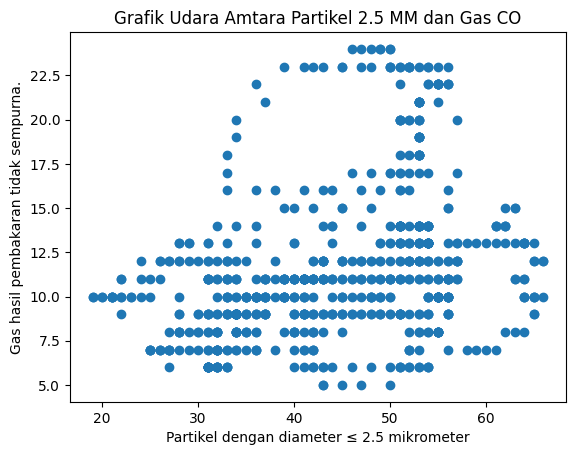

In [8]:
plt.scatter(df1['PM2.5'],df1['CO'])
plt.xlabel("Partikel dengan diameter ≤ 2.5 mikrometer")
plt.ylabel("Gas hasil pembakaran tidak sempurna.")
plt.title("Grafik Udara Amtara Partikel 2.5 MM dan Gas CO")

## Data Training

In [9]:
x_train = df1[['PM2.5', 'CO']].values

## Scalling

In [10]:
from sklearn.preprocessing import MinMaxScaler
Scalling = MinMaxScaler()

In [11]:
x_train = Scalling.fit_transform(x_train)

In [12]:
x_train

array([[0.55319149, 0.52631579],
       [0.53191489, 0.47368421],
       [0.5106383 , 0.47368421],
       ...,
       [0.74468085, 0.42105263],
       [0.74468085, 0.42105263],
       [0.74468085, 0.36842105]], shape=(720, 2))

## Memilih Clustering Menggunakan Elbow

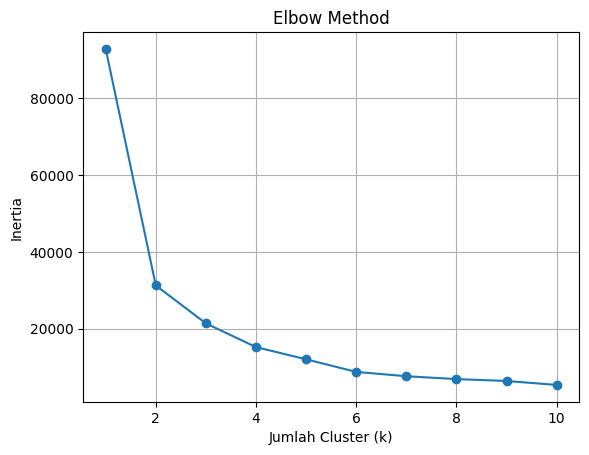

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df1[['PM2.5', 'CO']])
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


## Clustering

In [14]:
from sklearn.cluster import KMeans
kmean =KMeans(n_clusters=3)
kmean

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [15]:
Clusttering = kmean.fit_predict(x_train)

In [16]:
Clusttering

array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       2, 2, 2, 2, 1, 2, 2, 0, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,

### Buat Atribut Baru

In [18]:
df1['Hasil_Cluster'] = Clusttering

In [19]:
df1

,Date,Time,PM2.5,PM10,SO2,CO,O3,NO2,Max,Critical Component,Category,Hasil_Cluster
0,4/1/2021,00:00:00,45,19,21,15,8.0,3,21,PM2.5,Good,1
1,4/1/2021,01:00:00,44,18,20,14,8.0,3,20,PM2.5,Good,1
2,4/1/2021,02:00:00,43,17,20,14,7.0,3,20,PM2.5,Good,1
3,4/1/2021,03:00:00,40,17,20,13,7.0,3,20,PM2.5,Good,0
4,4/1/2021,04:00:00,38,16,19,12,7.0,3,19,PM2.5,Good,0
...,...,...,...,...,...,...,...,...,...,...,...,...
715,4/30/2021,19:00:00,54,23,17,14,21.0,4,23,PM2.5,Good,1
716,4/30/2021,20:00:00,54,23,17,14,21.0,4,23,PM2.5,Good,1
717,4/30/2021,21:00:00,54,23,17,13,21.0,4,23,PM2.5,Good,1
718,4/30/2021,22:00:00,54,23,17,13,21.0,4,23,PM2.5,Good,1


## 3 titik perklompok

In [21]:
kmean.cluster_centers_

array([[0.33450121, 0.23242988],
       [0.73101359, 0.31706871],
       [0.66500217, 0.80773362]])

## Visualisasi Data

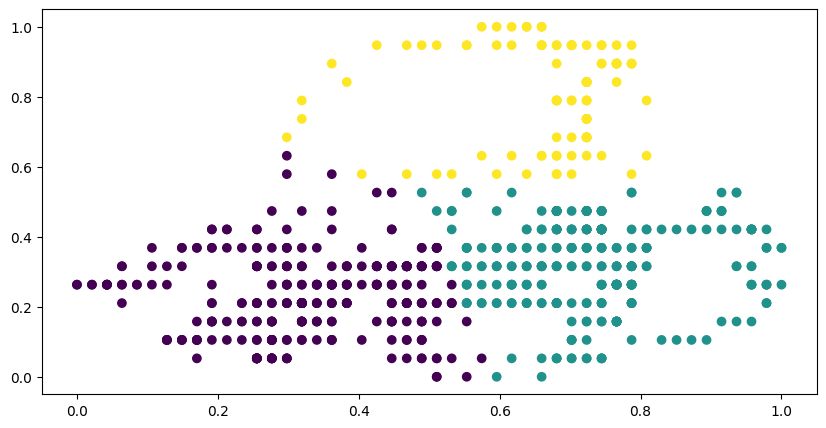

In [ ]:
plt.figure(figsize=(10,5))
plt.scatter(x_train[:,0],x_train[:,1], c=kmean.labels_)